In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import joblib
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [2]:
df=pd.read_csv(r"E:\medical_report_cnn\EEG\eeg\Epileptic Seizure Recognition.csv")

In [3]:
df.head()

,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,...,4,2,-12,-32,-41,-65,-83,-89,-73,5


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Columns: 180 entries, Unnamed to y
dtypes: int64(179), object(1)
memory usage: 15.8+ MB


In [5]:
df.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
count,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.00000,11500.00000,11500.000000,...,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000
mean,-11.581391,-10.911565,-10.187130,-9.143043,-8.009739,-7.003478,-6.502087,-6.68713,-6.55800,-6.168435,...,-10.145739,-11.630348,-12.943478,-13.668870,-13.363304,-13.045043,-12.705130,-12.426000,-12.195652,3.000000
std,165.626284,166.059609,163.524317,161.269041,160.998007,161.328725,161.467837,162.11912,162.03336,160.436352,...,164.652883,166.149790,168.554058,168.556486,167.257290,164.241019,162.895832,162.886311,164.852015,1.414275
min,-1839.000000,-1838.000000,-1835.000000,-1845.000000,-1791.000000,-1757.000000,-1832.000000,-1778.00000,-1840.00000,-1867.000000,...,-1867.000000,-1865.000000,-1642.000000,-1723.000000,-1866.000000,-1863.000000,-1781.000000,-1727.000000,-1829.000000,1.000000
25%,-54.000000,-55.000000,-54.000000,-54.000000,-54.000000,-54.000000,-54.000000,-55.00000,-55.00000,-54.000000,...,-55.000000,-56.000000,-56.000000,-56.000000,-55.000000,-56.000000,-55.000000,-55.000000,-55.000000,2.000000
50%,-8.000000,-8.000000,-7.000000,-8.000000,-8.000000,-8.000000,-8.000000,-8.00000,-7.00000,-7.000000,...,-9.000000,-10.000000,-10.000000,-10.000000,-10.000000,-9.000000,-9.000000,-9.000000,-9.000000,3.000000
75%,34.000000,35.000000,36.000000,36.000000,35.000000,36.000000,35.000000,36.00000,36.00000,35.250000,...,34.000000,34.000000,33.000000,33.000000,34.000000,34.000000,34.000000,34.000000,34.000000,4.000000
max,1726.000000,1713.000000,1697.000000,1612.000000,1518.000000,1816.000000,2047.000000,2047.00000,2047.00000,2047.000000,...,1777.000000,1472.000000,1319.000000,1436.000000,1733.000000,1958.000000,2047.000000,2047.000000,1915.000000,5.000000


In [6]:
df.shape

(11500, 180)

In [7]:
df.isnull().sum()

Unnamed    0
X1         0
X2         0
X3         0
X4         0
          ..
X175       0
X176       0
X177       0
X178       0
y          0
Length: 180, dtype: int64

In [9]:
df.drop("Unnamed",axis=1,inplace=True)

In [10]:
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,135,190,229,223,192,125,55,-9,-33,-38,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,386,382,356,331,320,315,307,272,244,232,...,164,150,146,152,157,156,154,143,129,1
2,-32,-39,-47,-37,-32,-36,-57,-73,-85,-94,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,-105,-101,-96,-92,-89,-95,-102,-100,-87,-79,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,-9,-65,-98,-102,-78,-48,-16,0,-21,-59,...,4,2,-12,-32,-41,-65,-83,-89,-73,5


In [11]:
print(df["y"].value_counts())

y
4    2300
1    2300
5    2300
2    2300
3    2300
Name: count, dtype: int64


In [12]:
df["y"] = df["y"].apply(lambda x: 1 if x==1 else 0)
print(df["y"].value_counts())

y
0    9200
1    2300
Name: count, dtype: int64


In [13]:
x = df.drop("y",axis=1)
y = df["y"]

In [14]:
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [15]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [16]:
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

In [17]:
x_train = x_train.reshape(x_train.shape[0], x_train.shape[1],1)
x_test = x_test.reshape(x_test.shape[0], x_test.shape[1],1)

In [18]:
model=Sequential()
model.add(Conv1D(filters=32,kernel_size=3,activation="relu",input_shape=(178,1)))
model.add(MaxPooling1D(2))
model.add(Conv1D(filters=64,kernel_size=3,activation="relu"))
model.add(MaxPooling1D(2))
model.add(Conv1D(filters=128,kernel_size=3,activation="relu"))
model.add(MaxPooling1D(2))
model.add(Flatten())
model.add(Dense(128,activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(64,activation="relu"))
model.add(Dropout(0.3))
model.add(Dense(1,activation="sigmoid"))

C:\Users\HP\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 176, 32)             │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 88, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 86, 64)              │           6,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 43, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 41, 128)             │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ (None, 20, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2560)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         327,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 367,169 (1.40 MB)

 Trainable params: 367,169 (1.40 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

In [21]:
early_stop=EarlyStopping(monitor="val_loss",patience=5,restore_best_weights=True)
checkpoint=ModelCheckpoint("best_eeg_model.keras",save_best_only=True)

In [22]:
history = model.fit(x_train, y_train, validation_split=0.2, epochs=25, batch_size=32, callbacks=[early_stop, checkpoint])

Epoch 1/25
230/230 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9340 - loss: 0.1779 - val_accuracy: 0.9462 - val_loss: 0.1219
Epoch 2/25
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9702 - loss: 0.0821 - val_accuracy: 0.9701 - val_loss: 0.0811
Epoch 3/25
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9792 - loss: 0.0641 - val_accuracy: 0.9745 - val_loss: 0.0624
Epoch 4/25
230/230 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9806 - loss: 0.0547 - val_accuracy: 0.9761 - val_loss: 0.0553
Epoch 5/25
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9838 - loss: 0.0484 - val_accuracy: 0.9799 - val_loss: 0.0579
Epoch 6/25
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9849 - loss: 0.0429 - val_accuracy: 0.9728 - val_loss: 0.0685
Epoch 7/25
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9885 - loss: 0.0344 - val_accuracy: 0.9810 - val_loss: 0.0507
Epoch 8/25
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9893 - loss: 0.0318 - val_accu

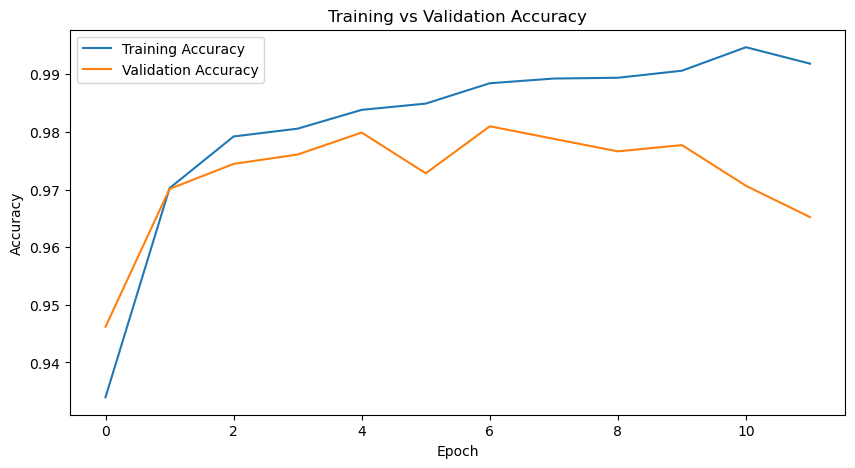

In [24]:
plt.figure(figsize=(10,5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

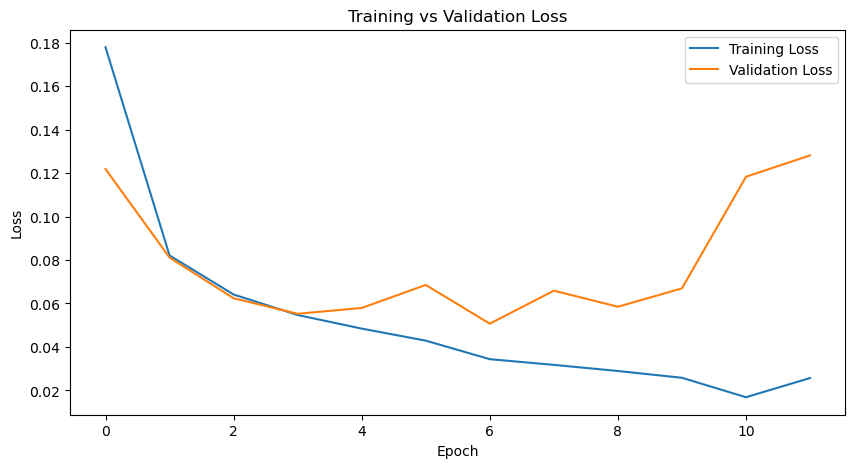

In [25]:
plt.figure(figsize=(10,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [26]:
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Loss : {loss:.4f}")
print(f"Test Accuracy : {accuracy*100:.2f}%")

72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9870 - loss: 0.0384
Test Loss : 0.0384
Test Accuracy : 98.70%


In [27]:
predictions = model.predict(x_test)
predicted_classes = (predictions > 0.5).astype(int)
predicted_classes = predicted_classes.flatten()

72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [28]:
model.save("eeg_model.keras")
print("Model Saved Successfully")

Model Saved Successfully


In [29]:
loaded_model = tf.keras.models.load_model("eeg_model.keras")
print("Model Loaded Successfully")

Model Loaded Successfully


In [30]:
sample = x_test[0]
sample = np.expand_dims(sample, axis=0)
prediction = loaded_model.predict(sample)
print(prediction)
if prediction[0][0] > 0.5:
    print("Seizure")
    print(f"Confidence : {prediction[0][0]*100:.2f}%")
else:
    print("Non-Seizure")
    print(f"Confidence : {(1-prediction[0][0])*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
[[0.07567951]]
Non-Seizure
Confidence : 92.43%


In [31]:
actual = y_test.iloc[0]
if actual == 1:
    print("Seizure")
else:
    print("Non-Seizure")

Non-Seizure


In [32]:
label_mapping = {0: "Non-Seizure",1: "Seizure"}
joblib.dump(label_mapping, "label_mapping.pkl")

['label_mapping.pkl']

In [33]:
history_df = pd.DataFrame(history.history)
history_df.to_csv("training_history.csv",index=False)